# Support Vector Classifier Implementation

In [1]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
# Let's create a synthetic data points
from sklearn.datasets import make_classification
X, y = make_classification(n_samples = 1000,
                           n_features = 2,
                           n_classes = 2,
                           n_clusters_per_class=2,
                           n_redundant = 0)

In [22]:
# Independent Features
X[:10]

array([[ 0.94606803,  1.20508462],
       [ 0.55040722, -0.4013977 ],
       [-0.92938779,  1.542337  ],
       [-1.28636827,  0.90753253],
       [-0.9150348 , -0.98783514],
       [ 1.50616103,  1.04254586],
       [-0.75284105, -1.13365214],
       [ 0.59923548, -0.61105171],
       [ 1.83092999,  1.12614741],
       [-1.66504012,  0.21197975]])

In [23]:
# Dependent Features
y[:10]

array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1])

<Axes: xlabel='0', ylabel='1'>

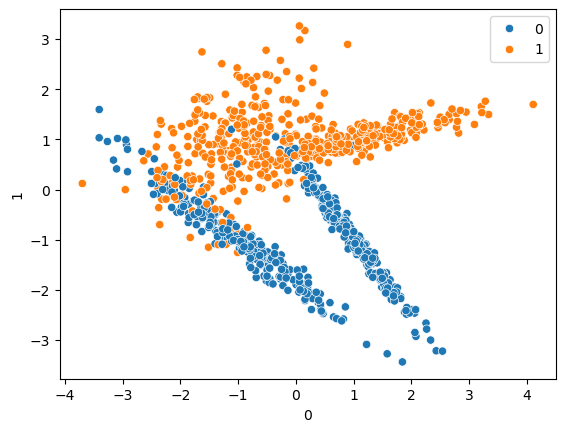

In [24]:
# visualize the dataset
sns.scatterplot(x = pd.DataFrame(X)[0], y = pd.DataFrame(X)[1], hue=y)

In [25]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [58]:
# model training
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [59]:
## Prediction
y_pred = svc.predict(X_test)

In [60]:
y_pred[:10]

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0])

In [61]:
y_test[:10]

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0])

In [62]:
# Performance Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
score = accuracy_score(y_test, y_pred)
print(score)

0.912


In [63]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[104  10]
 [ 12 124]]


In [64]:
# report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       114
           1       0.93      0.91      0.92       136

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



In [65]:
# kernal = 'rbf'
from sklearn.svm import SVC
svc = SVC(kernel='rbf')
svc.fit(X_train, y_train)
y_pred1 = svc.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       114
           1       0.97      0.92      0.94       136

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



In [68]:
# kernal = 'polynomial'
from sklearn.svm import SVC
svc = SVC(kernel='poly')
svc.fit(X_train, y_train)
y_pred2 = svc.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       114
           1       0.86      0.90      0.88       136

    accuracy                           0.87       250
   macro avg       0.87      0.86      0.87       250
weighted avg       0.87      0.87      0.87       250



In [69]:
# kernal = 'sigmoid'
from sklearn.svm import SVC
svc = SVC(kernel='sigmoid')
svc.fit(X_train, y_train)
y_pred3 = svc.predict(X_test)
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77       114
           1       0.82      0.78      0.80       136

    accuracy                           0.79       250
   macro avg       0.79      0.79      0.79       250
weighted avg       0.79      0.79      0.79       250



In [71]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel':['rbf']}

In [72]:
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5, verbose=3, refit=True)

In [73]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [74]:
# best params
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [75]:
# prediction
y_pred4 = grid.predict(X_test)
print(classification_report(y_test, y_pred4))
print(confusion_matrix(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       114
           1       0.97      0.93      0.95       136

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250

[[110   4]
 [  9 127]]
